# Anomaly Detection Industriale con Autoencoder Convoluzionali
**Studente:** Nicolae Balaban

## 1. Definizione del Problema e Dataset
In ambito manifatturiero, identificare difetti sui prodotti è cruciale. Tuttavia, gli approcci di classificazione supervisionata standard falliscono perché si hanno a disposizione migliaia di immagini di prodotti "sani" e pochissimi esempi di difetti.

Questo progetto affronta il problema tramite **Unsupervised Anomaly Detection**. Utilizzeremo un **Autoencoder Convoluzionale** addestrato esclusivamente su immagini perfette per fargli apprendere la distribuzione normale dei dati. In fase di test, le anomalie emergeranno come errori di ricostruzione.

**Dataset:** MVTec AD (Categoria: `bottle`).
*Nota: Il dataset non è incluso nel repository per limiti di dimensione. Può essere scaricato da Kaggle ed estratto nella cartella `data/bottle/`.*

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import torchvision.transforms as T
from torch.utils.data import DataLoader
from pathlib import Path

from utils.visual_util import ColoredPrint as cp
from utils.mvtec_dataset import MVTecDataset
from nets.simple_autoencoder import SimpleAutoencoder
from utils.dataset_analyzer import analyze_mvtec_category

BASE_DIR = Path.cwd()
DATA_ROOT = BASE_DIR / "data"
CATEGORY = "bottle"
MODEL_PATH = BASE_DIR / "runs" / "base_autoencoder.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
cp.cyan(f"Device: {device}")

Device: cuda


--- DATASET INFO: BOTTLE ---
Training images (only good one): 209

Test images:
  - broken_large: 20 images
  - broken_small: 22 images
  - contamination: 21 images
  - good: 20 images
Total test images: 83


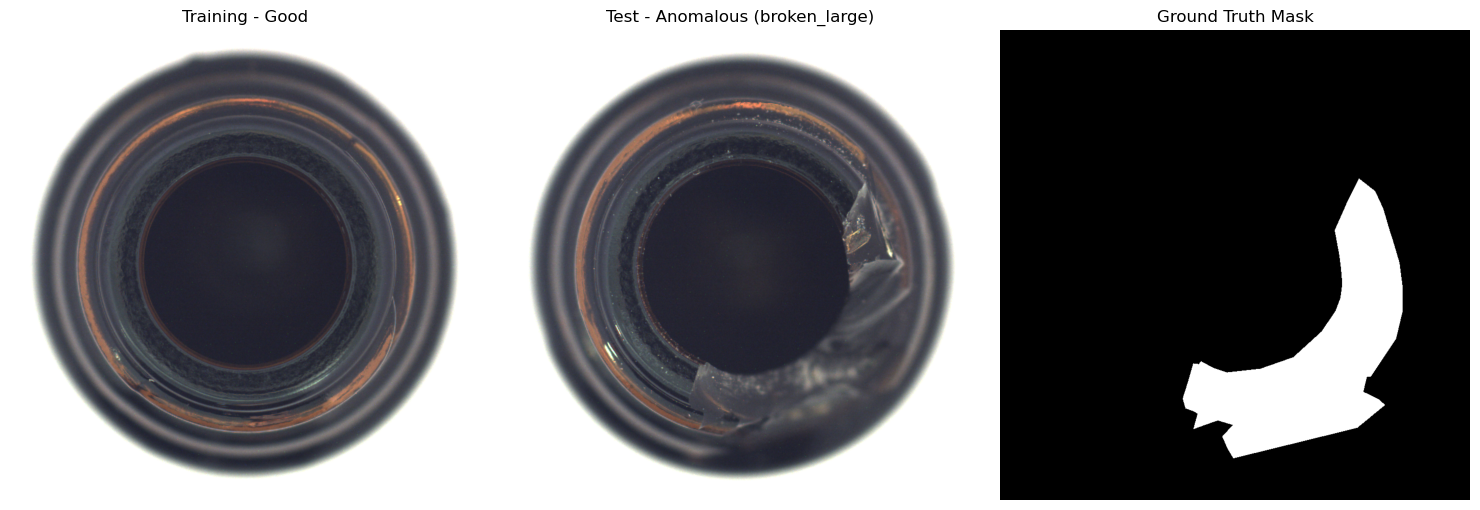

In [10]:
dataset_path = BASE_DIR / "data" / CATEGORY
analyze_mvtec_category(dataset_path)

## 2. Definizione del Problema
Come evidenziato dall'EDA, il dataset è **fortemente sbilanciato**. Abbiamo centinaia di esempi di bottiglie perfette nel training set, ma pochissimi esempi di difetti (e molto vari tra loro) nel test set. 

Un approccio di classificazione supervisionata standard fallirebbe per mancanza di dati sulle classi anomale.
Il problema viene quindi riformulato come **Unsupervised Anomaly Detection**:
1. Verra' addestrato un modello (Autoencoder) **solo** sulle immagini sane.
2. La rete imparerà a comprimere e ricostruire esclusivamente bottiglie perfette.
3. In fase di test, passando un'immagine difettosa, la rete fallirà nel ricostruire il difetto.
4. La differenza (Mean Squared Error) tra l'immagine originale e quella ricostruita genererà una *Anomaly Map*, permettendoci di isolare il difetto.

Evaluating of 83 test images...

--- EVALUATION RESULT ---
Dataset: BOTTLE
AUROC Score: 0.7825 (78.25%)
Average score error to reconstruct GOOD images: 0.3213
Average score error to reconstruct ANOMALOUS images: 0.3778


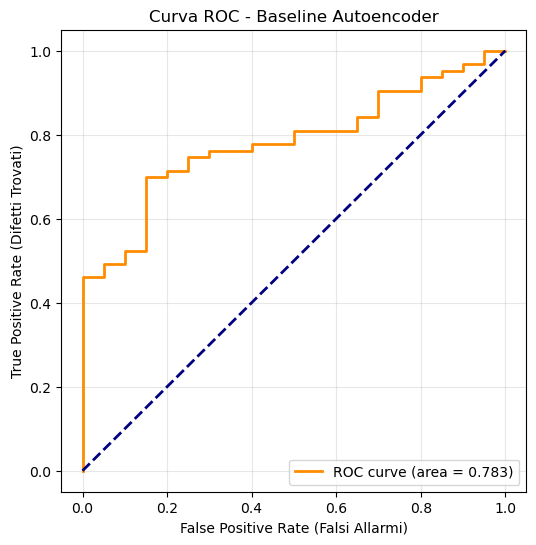

In [11]:
# 1. Caricamento del modello Baseline
model = SimpleAutoencoder().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval() # Modalità inferenza

# 2. Setup del DataLoader di Test (contiene sia bottiglie sane che rotte)
transform_pipeline = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

test_dataset = MVTecDataset(root_dir=DATA_ROOT, category=CATEGORY, is_train=False, transform=transform_pipeline)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

y_true = [] # Le etichette reali (0 = buone, 1 = anomalia)
y_scores = [] # Il punteggio di anomalia predetto

cp.yellow(f"Evaluating of {len(test_dataset)} test images...")

with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(device)

        reconstructed = model(images)

        # Calcoliamo l'errore quadratico (MSE) per ogni pixel nella singola immagine
        mse_map = (images - reconstructed) ** 2

        # Calcoliamo l'Anomaly Score: prendiamo la media degli errori per canale,
        # e poi il valore MASSIMO di tutta la mappa dell'immagine.
        # Se c'è un'anomalia, ci sarà almeno un pixel con un errore altissimo.
        mean_channels = torch.mean(mse_map, dim=1)
        anomaly_score = torch.max(mean_channels).item()

        y_true.append(labels.item())
        y_scores.append(anomaly_score)

auroc = roc_auc_score(y_true, y_scores)

cp.yellow("\n--- EVALUATION RESULT ---")
cp.cyan(f"Dataset: {CATEGORY.upper()}")
cp.cyan(f"AUROC Score: {auroc:.4f} ({auroc * 100:.2f}%)")

y_true_np = np.array(y_true)
y_scores_np = np.array(y_scores)
cp.cyan(f"Average score error to reconstruct GOOD images: {np.mean(y_scores_np[y_true_np == 0]):.4f}")
cp.cyan(f"Average score error to reconstruct ANOMALOUS images: {np.mean(y_scores_np[y_true_np == 1]):.4f}")


fpr, tpr, thresholds = roc_curve(y_true, y_scores)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auroc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Falsi Allarmi)')
plt.ylabel('True Positive Rate (Difetti Trovati)')
plt.title('Curva ROC - Baseline Autoencoder')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()